In [1]:
pip install langgraph langsmith

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install langchain langchain_groq langchain_community

  Using cached langchain_groq-1.1.2-py3-none-any.whl.metadata (2.4 kB)
  Using cached groq-0.37.1-py3-none-any.whl.metadata (16 kB)
Using cached langchain_groq-1.1.2-py3-none-any.whl (19 kB)
Using cached groq-0.37.1-py3-none-any.whl (137 kB)

  Attempting uninstall: groq

    Found existing installation: groq 1.1.2

    Uninstalling groq-1.1.2:

      Successfully uninstalled groq-1.1.2

   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   -

In [ ]:
groq_api_key='your_groq_api_key_here'
langsmith='your_langsmith_key_here'

In [4]:
from langchain_groq import ChatGroq

c:\Users\LIKHITH\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
llm=ChatGroq(groq_api_key=groq_api_key, model_name="Gemma2-9b-It")
llm

ChatGroq(profile={}, client=<groq.resources.chat.completions.Completions object at 0x000001DDD42E3C90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DDD2053610>, model_name='Gemma2-9b-It', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [7]:
class State(TypedDict):
  # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
  messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [8]:
graph_builder

In [9]:
def chatbot(state:State):
  return {"messages":llm.invoke(state['messages'])}

In [10]:
graph_builder.add_node("chatbot",chatbot)

In [11]:
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

In [12]:
graph=graph_builder.compile()

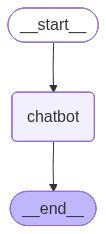

In [13]:
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass 

In [17]:
while True:
    user_input = input("User: ")

    if user_input.lower() in ["quit", "q"]:
        print("Good Bye")
        break

    for event in graph.stream({"messages": [("user", user_input)]}):
        for value in event.values():
            messages = value["messages"]

            # get last message
            last_msg = messages[-1]

            print("Assistant:", last_msg.content)

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}